# Recurrence Classifier with Validation

Not using clinical data since validation dataset doesn't have those features

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import *
from sklearn.pipeline import Pipeline

from recurrence_data import *

## Load Expression-Only Data

In [40]:
recurrence_data = load_recurrence_data()
data = recurrence_data["data"]

expression_features = recurrence_data["expression_features"]

X = data[expression_features].copy()
y = data[TARGET_COLUMN].astype(int)
groups = data[GROUP_COLUMN].astype(str)

val_data = load_validation_rec_data(
    train_expression_features=expression_features
)

X_val = val_data["X"]
y_val = val_data["y"]
val_meta = val_data["metadata"]

print("PNAS X:", X.shape)
print("PNAS labels:")
print(y.value_counts().rename(index={0: "Nonrecurrent", 1: "Recurrent"}))
print("PNAS donors:", groups.nunique())
print("Validation X:", X_val.shape)
print("Validation labels:")
print(y_val.value_counts().rename(index={0: "Nonrecurrent", 1: "Recurrent"}))
print("Validation columns match PNAS expression columns:", list(X_val.columns) == list(X.columns))
print("Overlapping expression features:", len(val_data["common_expression_features"]))
print("Missing expression features:", len(val_data["missing_expression_features"]))

PNAS X: (96, 42551)
PNAS labels:
recurrence_status
Nonrecurrent    68
Recurrent       28
Name: count, dtype: int64
PNAS donors: 44
Validation X: (83, 42551)
Validation labels:
recurrence_status
Nonrecurrent    75
Recurrent        8
Name: count, dtype: int64
Validation columns match PNAS expression columns: True
Overlapping expression features: 42551
Missing expression features: 0


## Train/Test Split and Evaluation Helper

In [41]:
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X,
    y,
    groups,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

trained_models = {}
pnas_results = []
validation_results = []


def evaluate_model(model, X_eval, y_eval, title):
    y_pred = model.predict(X_eval)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_eval)
    else:
        y_score = None

    metrics = {
        "model": title,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, y_score) if y_score is not None else np.nan,
    }

    conf_matrix = confusion_matrix(y_eval, y_pred)
    print(title)
    for metric_name in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        print(f"{metric_name}: {metrics[metric_name]:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)

    labels = np.array([["TN", "FP"], ["FN", "TP"]])
    annot_matrix = np.empty(conf_matrix.shape, dtype=object)
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            annot_matrix[i, j] = f"{conf_matrix[i, j]} ({labels[i, j]})"

    _, counts = np.unique(y_eval, return_counts=True)
    max_counts = max(counts)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_matrix,
        annot=annot_matrix,
        cmap="Blues",
        fmt="",
        annot_kws={"size": 15},
        vmin=0,
        vmax=max_counts,
    )
    plt.title(f"{title} Confusion Matrix", fontsize=18)
    plt.ylabel("Actual", fontsize=18)
    plt.xlabel("Predicted", fontsize=18)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.show()

    return metrics


print("y value counts:")
print(y.value_counts())
print("y_train value counts:")
print(y_train.value_counts())
print("y_test value counts:")
print(y_test.value_counts())
print("groups_train value counts:")
print(groups_train.value_counts())
print("groups_test value counts:")
print(groups_test.value_counts())

y value counts:
recurrence_status
0    68
1    28
Name: count, dtype: int64
y_train value counts:
recurrence_status
0    54
1    22
Name: count, dtype: int64
y_test value counts:
recurrence_status
0    14
1     6
Name: count, dtype: int64
groups_train value counts:
poiseid
2011    4
6027    4
6039    3
2018    3
6019    2
2048    2
2097    2
2005    2
6056    2
2002    2
2003    2
6021    2
2041    2
2060    2
6022    2
6017    2
6057    2
2065    2
6044    2
6060    2
2039    2
6035    2
6040    2
6062    2
2075    2
6045    2
6049    2
2028    2
2010    1
6043    1
2023    1
2014    1
2056    1
2006    1
6034    1
2038    1
6028    1
2031    1
2024    1
2091    1
6038    1
6023    1
Name: count, dtype: int64
groups_test value counts:
poiseid
2074    2
6025    2
2010    1
2056    1
6038    1
2024    1
2031    1
6043    1
6034    1
6028    1
2023    1
2038    1
2006    1
2091    1
2014    1
2018    1
6045    1
6023    1
Name: count, dtype: int64


# Whole Dataset

## Logistic Regression

LR CV ROC-AUC mean: 0.4970
LR CV ROC-AUC std: 0.1963
Classes: [0 1]
Logistic Regression - PNAS Test
accuracy: 0.6500
precision: 0.4000
recall: 0.3333
f1: 0.3636
roc_auc: 0.5952
Confusion Matrix:
[[11  3]
 [ 4  2]]


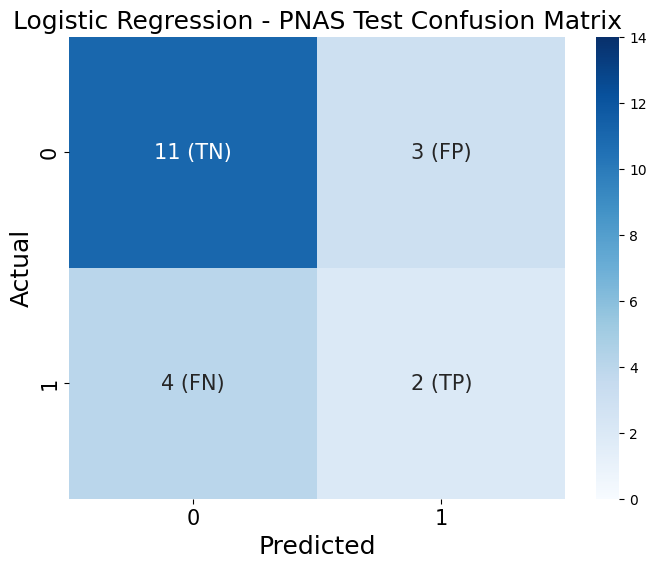

In [42]:
LR_Model = Pipeline([
    ("select", SelectKBest(score_func=f_classif, k=10)),
    ("scaler", MinMaxScaler()),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear", penalty="l1", C=1.0)),
])

LR_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
LR_cross_scores = cross_val_score(
    LR_Model,
    X_train,
    y_train,
    cv=LR_cv,
    groups=groups_train,
    scoring="roc_auc",
)
print(f"LR CV ROC-AUC mean: {LR_cross_scores.mean():.4f}")
print(f"LR CV ROC-AUC std: {LR_cross_scores.std():.4f}")

LR_Model.fit(X_train, y_train)
trained_models["Logistic Regression"] = LR_Model
print("Classes:", LR_Model.named_steps["classifier"].classes_)

pnas_results.append(evaluate_model(LR_Model, X_test, y_test, "Logistic Regression - PNAS Test"))

## Random Forest

RF CV ROC-AUC mean: 0.4737
RF CV ROC-AUC std: 0.1748
Random Forest - PNAS Test
accuracy: 0.7000
precision: 0.5000
recall: 0.1667
f1: 0.2500
roc_auc: 0.6667
Confusion Matrix:
[[13  1]
 [ 5  1]]


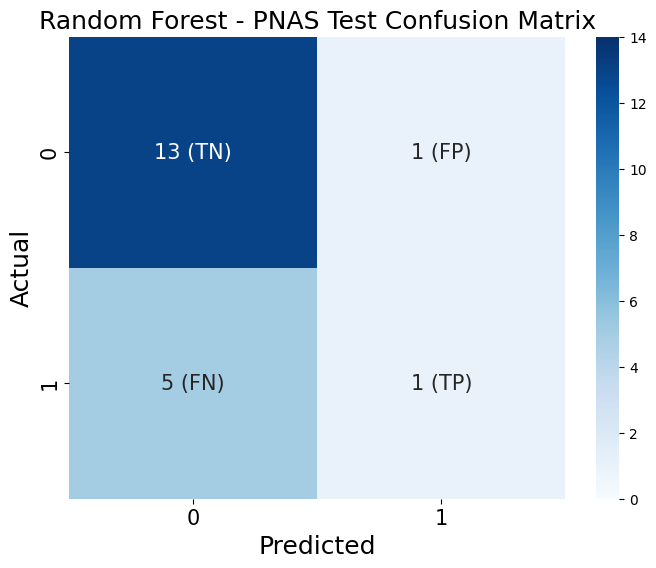

In [43]:
RF_Model = Pipeline([
    ("select", SelectKBest(score_func=f_classif, k=10)),
    ("rf", RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        max_depth=None,       
        min_samples_leaf=1,    
        max_features="sqrt",  
    )),
])

RF_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
RF_cross_scores = cross_val_score(
    RF_Model,
    X_train,
    y_train,
    cv=RF_cv,
    groups=groups_train,
    scoring="roc_auc",
)
print(f"RF CV ROC-AUC mean: {RF_cross_scores.mean():.4f}")
print(f"RF CV ROC-AUC std: {RF_cross_scores.std():.4f}")

RF_Model.fit(X_train, y_train)
trained_models["Random Forest"] = RF_Model

pnas_results.append(evaluate_model(RF_Model, X_test, y_test, "Random Forest - PNAS Test"))

## Naive Bayes

NB CV ROC-AUC mean: 0.4213
NB CV ROC-AUC std: 0.1806
Naive Bayes - PNAS Test
accuracy: 0.6000
precision: 0.4000
recall: 0.6667
f1: 0.5000
roc_auc: 0.6369
Confusion Matrix:
[[8 6]
 [2 4]]


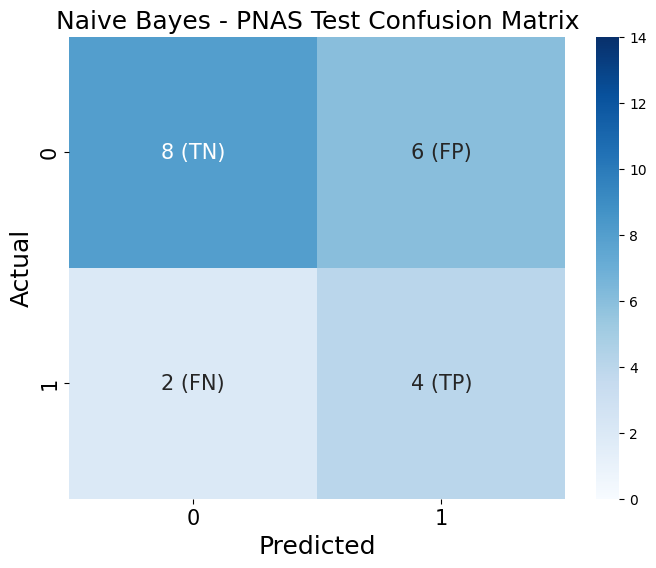

In [44]:
NB_Model = Pipeline([
    ("select", SelectKBest(score_func=f_classif, k=10)),
    ("scaler", MinMaxScaler()),
    ("classifier", GaussianNB()),
])
NB_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
NB_cross_scores = cross_val_score(
    NB_Model,
    X_train,
    y_train,
    cv=NB_cv,
    groups=groups_train,
    scoring="roc_auc",
)
print(f"NB CV ROC-AUC mean: {NB_cross_scores.mean():.4f}")
print(f"NB CV ROC-AUC std: {NB_cross_scores.std():.4f}")

NB_Model.fit(X_train, y_train)
trained_models["Naive Bayes"] = NB_Model

pnas_results.append(evaluate_model(NB_Model, X_test, y_test, "Naive Bayes - PNAS Test"))

## Support Vector Machine

SVM CV ROC-AUC mean: 0.4513
SVM CV ROC-AUC std: 0.1794
Support Vector Machine - PNAS Test
accuracy: 0.6000
precision: 0.3750
recall: 0.5000
f1: 0.4286
roc_auc: 0.6786
Confusion Matrix:
[[9 5]
 [3 3]]


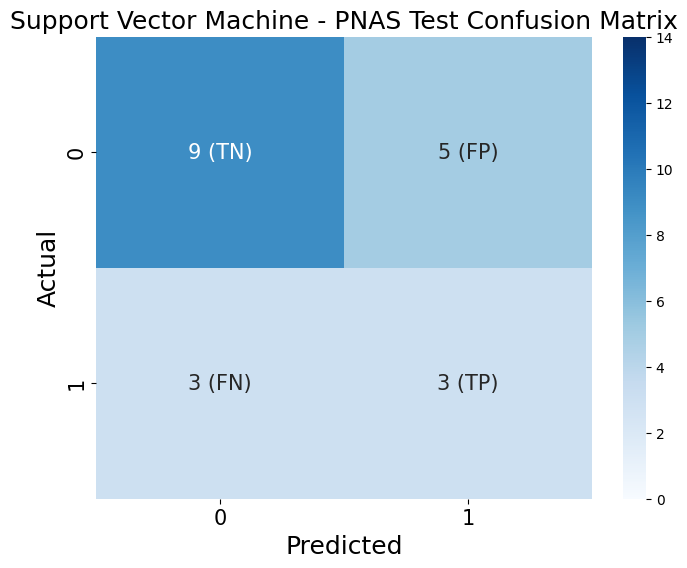

In [45]:
SVM_Model = Pipeline([
    ("select", SelectKBest(score_func=f_classif, k=10)),
    ("scaler", MinMaxScaler()),
    ("classifier", SVC(
        kernel="rbf",         
        C=1.0,             
        gamma="scale",     
        probability=True,
        class_weight="balanced",
        random_state=42,
    )),
])

SVM_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
SVM_cross_scores = cross_val_score(
    SVM_Model,
    X_train,
    y_train,
    cv=SVM_cv,
    groups=groups_train,
    scoring="roc_auc",
)
print(f"SVM CV ROC-AUC mean: {SVM_cross_scores.mean():.4f}")
print(f"SVM CV ROC-AUC std: {SVM_cross_scores.std():.4f}")

SVM_Model.fit(X_train, y_train)
trained_models["Support Vector Machine"] = SVM_Model

pnas_results.append(evaluate_model(SVM_Model, X_test, y_test, "Support Vector Machine - PNAS Test"))

## PNAS Test Set Summary

In [46]:
pnas_results_df = pd.DataFrame(pnas_results).set_index("model")
print(pnas_results_df)

                                    accuracy  precision    recall        f1  \
model                                                                         
Logistic Regression - PNAS Test         0.65      0.400  0.333333  0.363636   
Random Forest - PNAS Test               0.70      0.500  0.166667  0.250000   
Naive Bayes - PNAS Test                 0.60      0.400  0.666667  0.500000   
Support Vector Machine - PNAS Test      0.60      0.375  0.500000  0.428571   

                                     roc_auc  
model                                         
Logistic Regression - PNAS Test     0.595238  
Random Forest - PNAS Test           0.666667  
Naive Bayes - PNAS Test             0.636905  
Support Vector Machine - PNAS Test  0.678571  


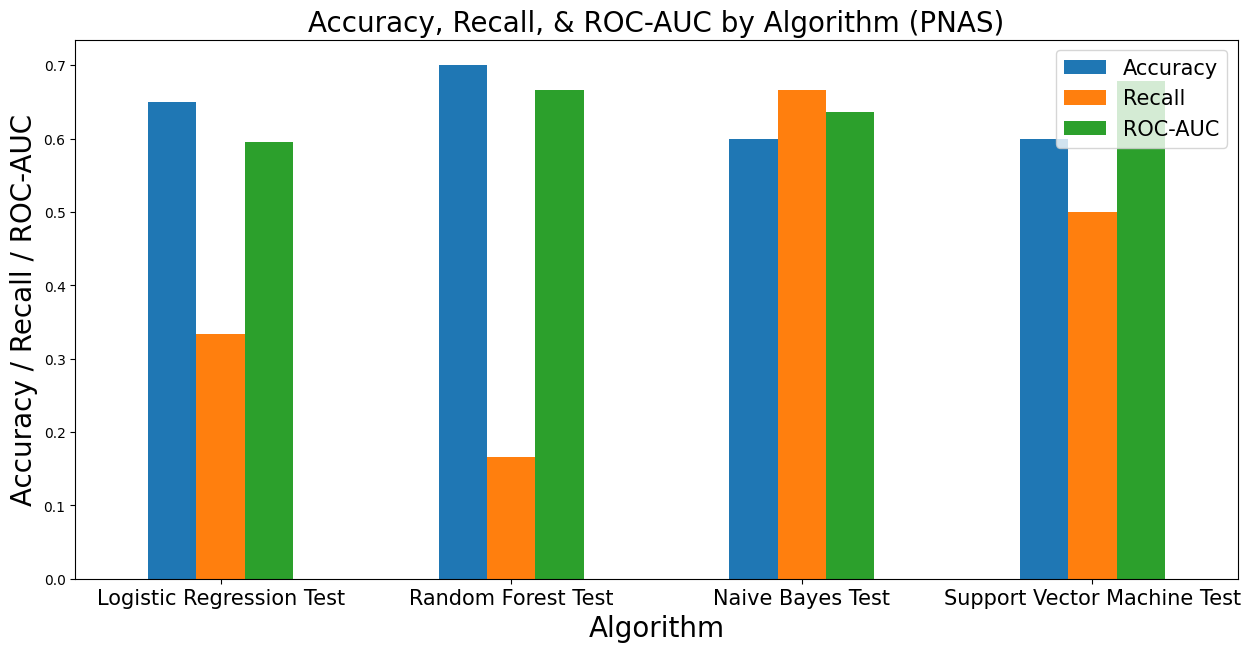

In [47]:
plot_df = pnas_results_df.reset_index().rename(columns={"model": "Algorithm"})
plot_df["Algorithm"] = plot_df["Algorithm"].str.replace(" - PNAS", "", regex=False)

plot_df = plot_df[["Algorithm", "accuracy", "recall", "roc_auc"]].rename(columns={
    "accuracy": "Accuracy",
    "recall": "Recall",
    "roc_auc": "ROC-AUC",
})

plot_df.plot(
    kind="bar",
    x="Algorithm",
    y=["Accuracy", "Recall", "ROC-AUC"],
    figsize=(15, 7),
    rot=0
)
plt.xlabel("Algorithm", fontsize=20)
plt.ylabel("Accuracy / Recall / ROC-AUC", fontsize=20)
plt.title("Accuracy, Recall, & ROC-AUC by Algorithm (PNAS)", fontsize=20)
plt.xticks(fontsize=15)
plt.legend(fontsize=15)
plt.show()

# Validation Dataset Evaluation

Validation X: (83, 42551)
Validation labels:
recurrence_status
Nonrecurrent    75
Recurrent        8
Name: count, dtype: int64
Overlapping expression features: 42551
Missing expression features: 0
Validation columns match training columns: True
Logistic Regression - Validation
accuracy: 0.5181
precision: 0.0556
recall: 0.2500
f1: 0.0909
roc_auc: 0.4600
Confusion Matrix:
[[41 34]
 [ 6  2]]


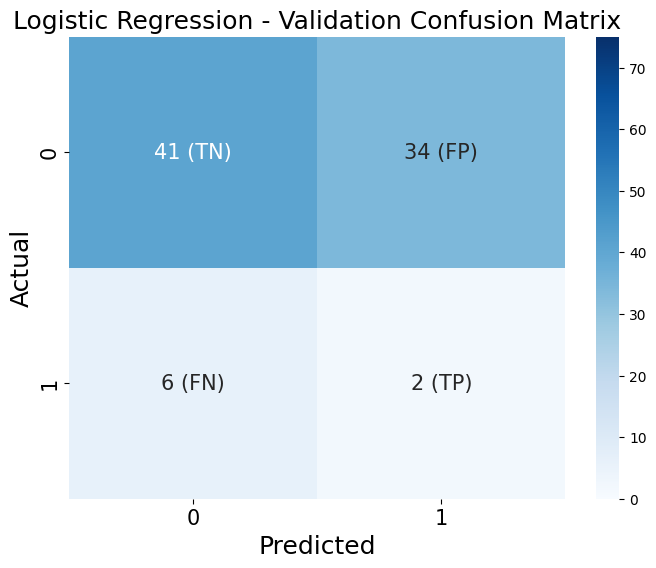

Random Forest - Validation
accuracy: 0.7470
precision: 0.1176
recall: 0.2500
f1: 0.1600
roc_auc: 0.6033
Confusion Matrix:
[[60 15]
 [ 6  2]]


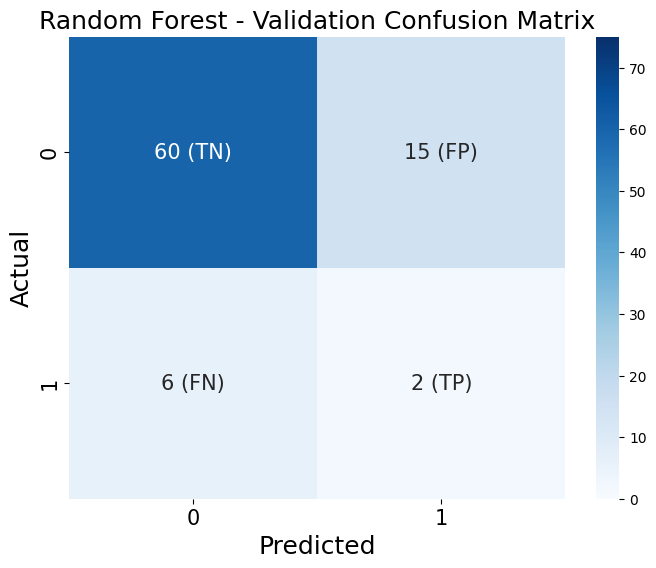

Naive Bayes - Validation
accuracy: 0.5301
precision: 0.0811
recall: 0.3750
f1: 0.1333
roc_auc: 0.4883
Confusion Matrix:
[[41 34]
 [ 5  3]]


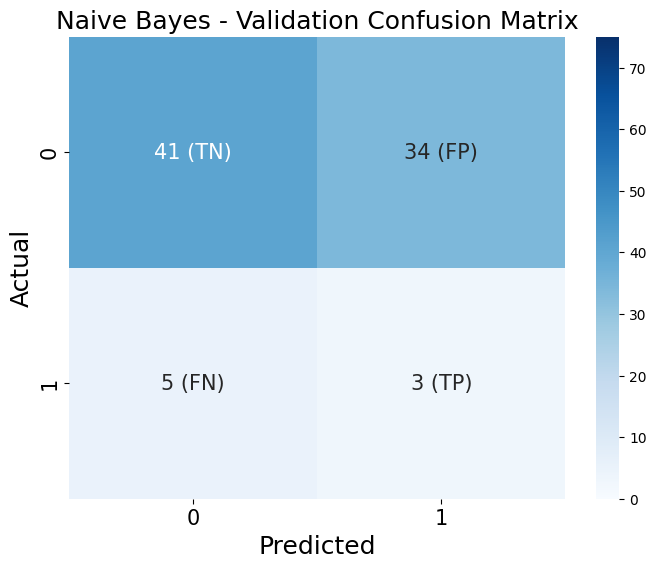

Support Vector Machine - Validation
accuracy: 0.5542
precision: 0.1463
recall: 0.7500
f1: 0.2449
roc_auc: 0.6100
Confusion Matrix:
[[40 35]
 [ 2  6]]


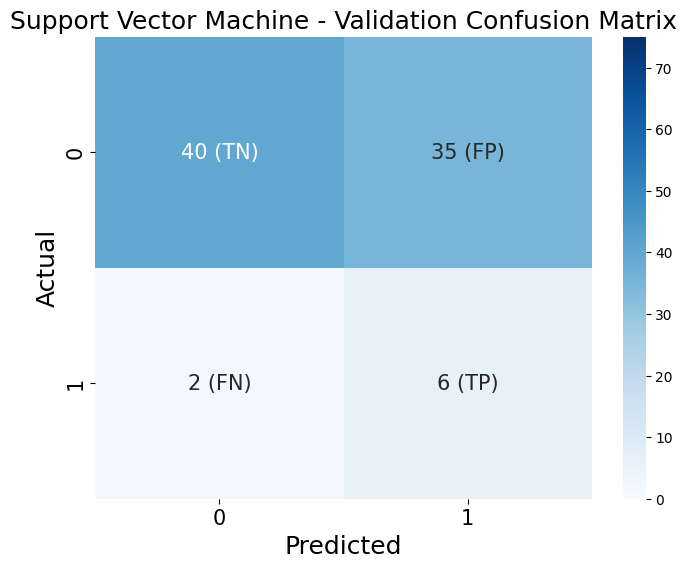

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression - Validation,0.518072,0.055556,0.250,0.090909,0.460000
Random Forest - Validation,0.746988,0.117647,0.250,0.160000,0.603333
Naive Bayes - Validation,0.530120,0.081081,0.375,0.133333,0.488333
Support Vector Machine - Validation,0.554217,0.146341,0.750,0.244898,0.610000


In [48]:
print("Validation X:", X_val.shape)
print("Validation labels:")
print(y_val.value_counts().rename(index={0: "Nonrecurrent", 1: "Recurrent"}))
print("Overlapping expression features:", len(val_data["common_expression_features"]))
print("Missing expression features:", len(val_data["missing_expression_features"]))
print("Validation columns match training columns:", list(X_val.columns) == list(X.columns))

for model_name, model in trained_models.items():
    validation_results.append(
        evaluate_model(model, X_val, y_val, f"{model_name} - Validation")
    )

validation_results_df = pd.DataFrame(validation_results).set_index("model")
validation_results_df

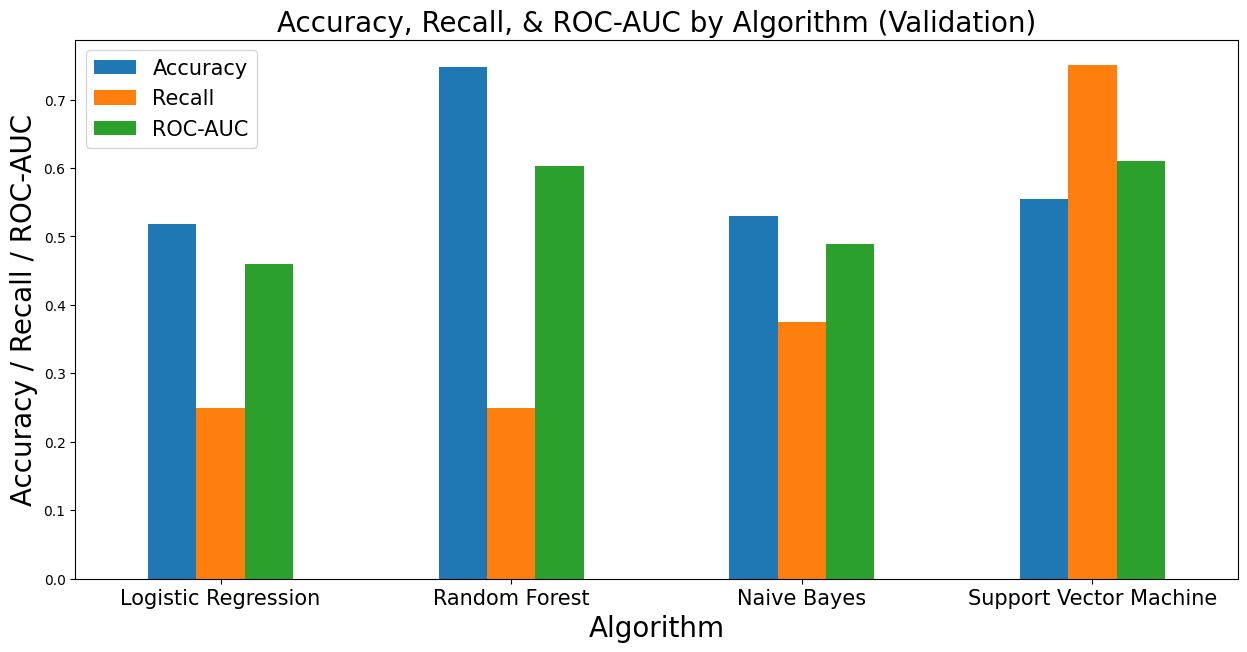

In [49]:
plot_df = validation_results_df.reset_index().rename(columns={"model": "Algorithm"})
plot_df["Algorithm"] = plot_df["Algorithm"].str.replace(" - Validation", "", regex=False)

plot_df = plot_df[["Algorithm", "accuracy", "recall", "roc_auc"]].rename(columns={
    "accuracy": "Accuracy",
    "recall": "Recall",
    "roc_auc": "ROC-AUC",
})

plot_df.plot(
    kind="bar",
    x="Algorithm",
    y=["Accuracy", "Recall", "ROC-AUC"],
    figsize=(15, 7),
    rot=0
)
plt.xlabel("Algorithm", fontsize=20)
plt.ylabel("Accuracy / Recall / ROC-AUC", fontsize=20)
plt.title("Accuracy, Recall, & ROC-AUC by Algorithm (Validation)", fontsize=20)
plt.xticks(fontsize=15)
plt.legend(fontsize=15)
plt.show()

## Tuning Best Model

In [ ]:
svm_param_grid = {
    "select__k": [5, 10, 20, 50, 100, 250, 500, 1000],
    "classifier__C": [0.1, 1, 5, 10],
    "classifier__gamma": ["scale", 0.01, 0.001],
}

svm_inner_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

SVM_tuned = GridSearchCV(
    estimator=SVM_Model,             
    param_grid=svm_param_grid,
    scoring="roc_auc",          
    cv=svm_inner_cv,
    n_jobs=-1,
    refit=True,
)

SVM_tuned.fit(X_train, y_train, groups=groups_train)

print("Tuned SVM best params:", SVM_tuned.best_params_)
print("Tuned SVM best CV ROC-AUC:", SVM_tuned.best_score_)

In [ ]:
val_proba_tuned = SVM_tuned.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba_tuned)

target_recall = 0.75  # choose your desired recall level
candidate_idxs = [i for i, r in enumerate(recalls) if r >= target_recall]

if candidate_idxs:
    thr_idx = candidate_idxs[0]
    best_threshold = thresholds[thr_idx]
    print(f"Chosen threshold for recall ≥ {target_recall}: {best_threshold:.4f}")
    print(f"Precision at this threshold: {precisions[thr_idx]:.4f}")
    print(f"Recall at this threshold: {recalls[thr_idx]:.4f}")
else:
    best_threshold = 0.5
    print(f"Could not reach recall ≥ {target_recall}; using 0.5")

In [ ]:
def predict_with_threshold(model, X, threshold):
    proba = model.predict_proba(X)[:, 1]
    return (proba >= threshold).astype(int)

y_val_pred_custom = predict_with_threshold(SVM_tuned, X_val, best_threshold)

print("Validation performance for tuned SVM with custom threshold:")
print(classification_report(y_val, y_val_pred_custom, target_names=["Nonrecurrent", "Recurrent"]))